# 03. Hardware Constraints (NISQ) and Error Mitigation via Zero-Noise Extrapolation (ZNE)
### Master's Thesis: Quantum Bayesian Inference and Amplitude Estimation (QAE) in Astrobiology
**Author:** Daniel Rivero Losa  
**Supervisor:** Roberto Campos Ortiz  
**Institution:** Universidad Antonio de Nebrija — Escuela Politécnica Superior  
**Reference Section:** Section 4.4 of Master's Thesis (*Hardware Constraints, Noise Modeling & Zero-Noise Extrapolation*)  

---
### 📌 Executive Summary
This third notebook completes the experimental suite of the Master's Thesis by transitioning ideal theoretical models into **physical operating conditions of Noisy Intermediate-Scale Quantum (NISQ) processors**.

The dual objective is:
1. **Model physical degradation induced by environmental decoherence:** Implement a realistic thermodynamic and gate noise model calibrated against superconducting processor parameters from **IBM Quantum** (relaxation time $T_1$, dephasing time $T_2$, single-qubit and two-qubit depolarizing gate errors, and readout infidelities), demonstrating how environmental decoherence and depolarizing mixing flatten the inferential distribution toward the maximally mixed state.
2. **Mitigate noise via Zero-Noise Extrapolation (ZNE):** Implement native **Global Circuit Folding** ($U \to U (U^\dagger U)^k$) and **second-order Richardson polynomial extrapolation**, projecting noisy expectation values backward to the theoretical zero-noise limit ($\lambda \to 0$) to recover the true astrobiological signal without requiring auxiliary physical qubits or Fault-Tolerant Quantum Error Correction (FTQC).

## 1. Section 4.4.1: Physical Noise Modeling in Superconducting Processors

In transmon-based superconducting quantum processors (such as IBM Eagle or Falcon architectures), environmental thermodynamic coupling and microwave control pulses introduce coherence degradation:

### 1.1 Thermodynamic Channels and Coherence Horizons
1. **Thermal Relaxation ($T_1$):** Spontaneous decay of the excited state $|1\rangle$ to the ground state $|0\rangle$ via dipole coupling to cryostat thermal radiation modes:
   $$\rho(t)_{11} = \rho(0)_{11} e^{-t / T_1}$$
   Calibrated contemporary baseline: $T_1 \approx 150 \ \mu\text{s}$.
2. **Pure Dephasing ($T_2$):** Low-frequency magnetic flux fluctuations that randomize the quantum phase in the equatorial plane of the Bloch sphere:
   $$\frac{1}{T_2} = \frac{1}{2 T_1} + \frac{1}{T_2^*}, \quad T_2 \le 2 T_1$$
   Calibrated contemporary baseline: $T_2 \approx 120 \ \mu\text{s}$.

### 1.2 Gate Infidelities and Depolarization Channels
- **Single-Qubit Gates ($R_y, X, H, SX$):** Microwave pulse duration $t_1 \approx 35\text{ ns}$, with depolarizing error rate $p_1 \approx 0.08\%$.
- **Two-Qubit Gates (CNOT, $CX$):** Cross-resonance driving with duration $t_{cx} \approx 300\text{ ns}$, with dominant depolarizing error rate $p_2 \approx 1.20\%$.
- **Depolarizing Channel:**
   $$\mathcal{E}_{\text{dep}}(\rho) = (1 - p) \rho + \frac{p}{2^n} I_{2^n}$$

### 1.3 Readout Error
During dispersive cavity readout, thermal noise causes classical bit-flip measurement errors: $P(1|0) \approx 1.5\%$ and $P(0|1) \approx 1.0\%$.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, thermal_relaxation_error, depolarizing_error, ReadoutError
import matplotlib.pyplot as plt

# 1. Deterministic random seeds for exact reproducibility
np.random.seed(100)
GLOBAL_SEED = 100

# 2. Calibrated physical parameters (IBM Quantum Processor Metrics, Section 4.4.1)
t1 = 150e-6        # T1 = 150 microseconds
t2 = 120e-6        # T2 = 120 microseconds
time_u = 35e-9     # 1-qubit gate duration: 35 ns
time_cx = 300e-9   # 2-qubit CNOT gate duration: 300 ns

prob_dep_1q = 0.0008  # 1-qubit depolarization rate (0.08%)
prob_dep_2q = 0.0120  # 2-qubit depolarization rate (1.20%)

prob_ro_01 = 0.015    # P(read 1 | state is 0)
prob_ro_10 = 0.010    # P(read 0 | state is 1)

# 3. Thermodynamic and depolarization channels
thermal_u = thermal_relaxation_error(t1, t2, time_u)
thermal_cx = thermal_relaxation_error(t1, t2, time_cx).expand(
             thermal_relaxation_error(t1, t2, time_cx))

depol_u = depolarizing_error(prob_dep_1q, 1)
depol_cx = depolarizing_error(prob_dep_2q, 2)

error_u = thermal_u.compose(depol_u)
error_cx = thermal_cx.compose(depol_cx)

# Readout Error
readout_err = ReadoutError([[1.0 - prob_ro_01, prob_ro_01],
                            [prob_ro_10, 1.0 - prob_ro_10]])

# 4. Construction of complete NoiseModel
nisq_noise_model = NoiseModel()
nisq_noise_model.add_all_qubit_quantum_error(error_u, ['u1', 'u2', 'u3', 'h', 'ry', 'x', 'z', 'rz', 'sx'])
nisq_noise_model.add_all_qubit_quantum_error(error_cx, ['cx', 'cz'])
nisq_noise_model.add_all_qubit_readout_error(readout_err)

noisy_backend = AerSimulator(noise_model=nisq_noise_model, seed_simulator=GLOBAL_SEED)
ideal_backend = AerSimulator(method='statevector', seed_simulator=GLOBAL_SEED)

# Dual export helper for thesis and root figure repositories
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..')) if os.path.exists('../../thesis') else (
            os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.exists('../thesis') else (
            os.path.abspath(os.getcwd()) if os.path.exists('thesis') else '.'))

def export_figure(fig, relative_targets, **kwargs):
    from PIL import Image
    for rel_path in relative_targets:
        full_path = os.path.join(repo_root, rel_path)
        os.makedirs(os.path.dirname(full_path), exist_ok=True)
        fig.savefig(full_path, **kwargs)
        if 'circuit' in rel_path:
            im = Image.open(full_path)
            if im.width > 2200 or im.height > 2200:
                ratio = min(2200 / im.width, 2200 / im.height)
                new_size = (int(im.width * ratio), int(im.height * ratio))
                im_resized = im.resize(new_size, Image.Resampling.LANCZOS)
                im_resized.save(full_path, optimize=True)
        print(f"✓ Figure saved to: {full_path}")

print("="*65)
print(" CONFIGURED NISQ NOISE MODEL (IBM Quantum Parameters)")
print("="*65)
print(f" Longitudinal Relaxation Time T1 : {t1*1e6:.1f} us")
print(f" Transverse Dephasing Time T2    : {t2*1e6:.1f} us")
print(f" Gate Durations (1Q / 2Q)        : {time_u*1e9:.0f} ns / {time_cx*1e9:.0f} ns")
print(f" CNOT Depolarization Error Rate  : {prob_dep_2q*100:.2f}%")
print(f" Mean Readout Inversion Error    : {(prob_ro_01+prob_ro_10)/2*100:.2f}%")
print(" Deterministic Noisy NISQ backend initialized successfully.")
print("="*65)

 CONFIGURED NISQ NOISE MODEL (IBM Quantum Parameters)
 Longitudinal Relaxation Time T1 : 150.0 us
 Transverse Dephasing Time T2    : 120.0 us
 Gate Durations (1Q / 2Q)        : 35 ns / 300 ns
 CNOT Depolarization Error Rate  : 1.20%
 Mean Readout Inversion Error    : 1.25%
 Deterministic Noisy NISQ backend initialized successfully.


## 2. Section 4.4.2: Astrobiological Inference Kernel for NISQ Benchmarking

As demonstrated in **Section 4.3.9**, the canonical 17-qubit QAE circuit requires **52,393 compiled physical gates**.  
On contemporary physical NISQ hardware, where coherence windows tolerate approximately $\sim 500$ to $1,500$ gates before wavefunction collapse into pure entropy, executing 52,000 gates yields complete decoherence.

Therefore, to rigorously benchmark physical noise degradation and demonstrate algorithmic **Zero-Noise Extrapolation**, we isolate the **fundamental causal Bayesian inference kernel of K2-18b**:
1. **State Register ($n_S = 4$ qubits):** Representative exoplanetary Bayesian network subset:
   - $q_0$: Stellar spectral type (M-Dwarf, $P = 0.75$).
   - $q_1$: Liquid habitable zone (HZ, $P = 0.20$).
   - $q_2$: Hycean planet condition (conditioned on $q_0$ and $q_1$).
   - $q_3$: Active marine biosignature / biomarker indicator ($P \approx 0.060$).
2. **Ancilla Register ($q_4$):** Phase kickback marker qubit.
3. **Grover Reflection Operator ($\mathcal{Q}$):** One complete iteration of $\mathcal{Q} = -\mathcal{A} S_0 \mathcal{A}^\dagger S_\chi$, executed within an accessible depth ($D = 39$ native gates) within current NISQ operational limits.

 IDEAL BASELINE (GROUND TRUTH WITHOUT NOISE)
 Circuit Logical Depth               : 8 gates
 Total Elementary Operations         : 17 gates
 Ideal Counts (8,192 shots)          : {'0': 7676, '1': 516}
 Ideal Probability P(Biomarker=1)    : 0.062988 (6.30%)
 Ideal Expectation Value <Z>         : 0.874023

Generating graphical diagram of the base inference circuit...
✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/figures/circuits/circuit_nisq_base.png
✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/thesis/figures/4.system_architecture/circuit_nisq_base.png


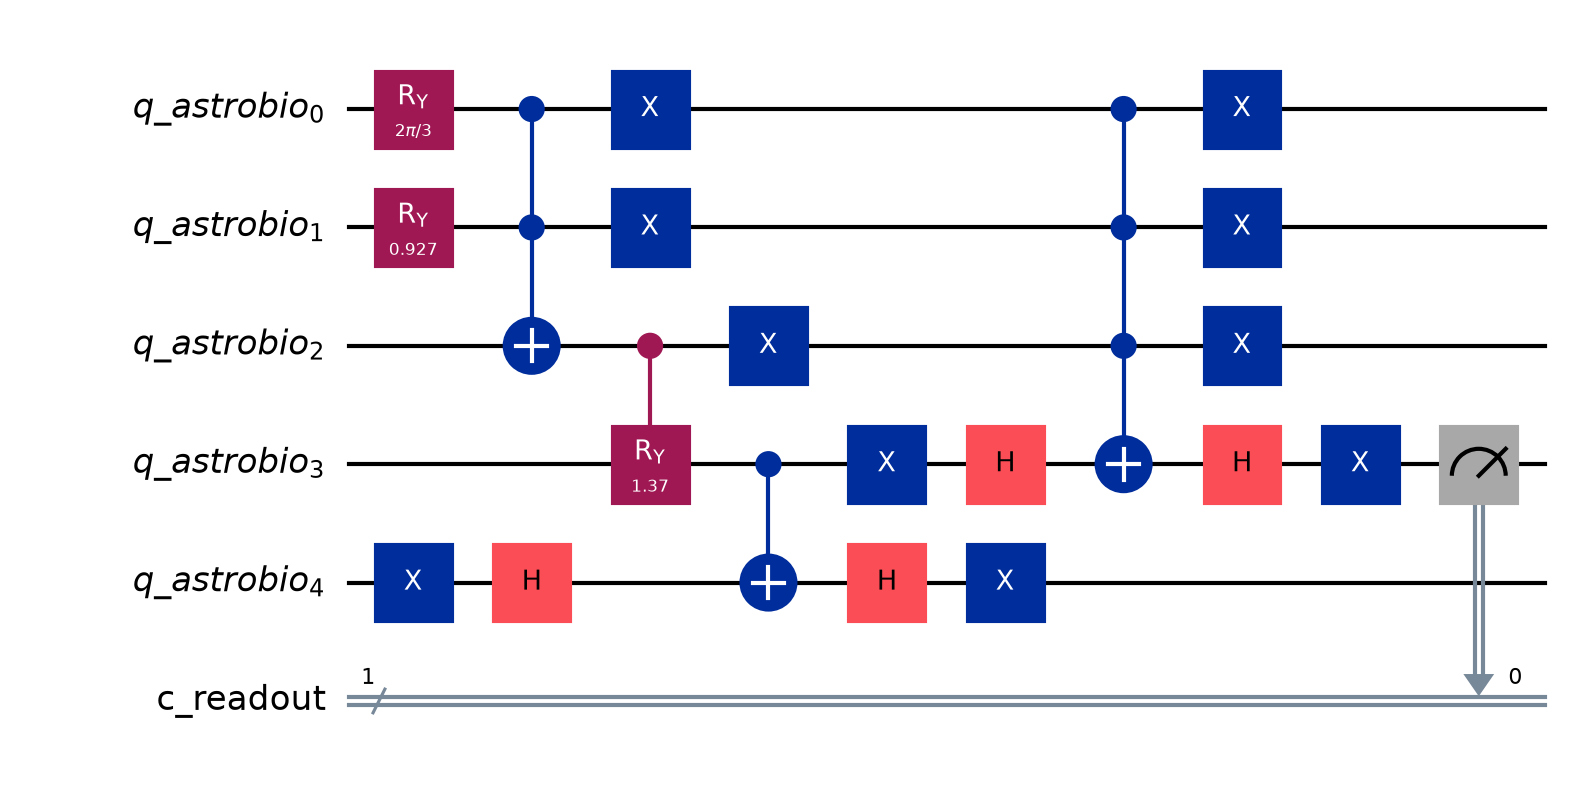

In [2]:
def build_k218b_inference_kernel():
    """Constructs the representative K2-18b Bayesian inference kernel with Grover operator."""
    qr = QuantumRegister(5, name='q_astrobio')
    cr = ClassicalRegister(1, name='c_readout')
    qc = QuantumCircuit(qr, cr)

    # 1. Operator A: K2-18b Bayesian Inference
    # Node 0 (M Star, P=0.75) and Node 1 (Habitable Zone, P=0.20)
    qc.ry(2.0 * np.arcsin(np.sqrt(0.75)), qr[0])
    qc.ry(2.0 * np.arcsin(np.sqrt(0.20)), qr[1])

    # Node 2 (Hycean): CNOT conditioned on Star and Habitable Zone
    qc.ccx(qr[0], qr[1], qr[2])

    # Node 3 (Biomarker): Activated by Hycean condition with probabilistic rotation
    qc.cry(2.0 * np.arcsin(np.sqrt(0.40)), qr[2], qr[3])

    # 2. Oracle S_chi: Marks the detected biomarker state in q3 using ancilla q4
    qc.x(qr[4])
    qc.h(qr[4])
    qc.cx(qr[3], qr[4])  # Phase kickback (-1)
    qc.h(qr[4])
    qc.x(qr[4])

    # 3. Diffuser S_0: Reflection about the zero state
    qc.x([qr[0], qr[1], qr[2], qr[3]])
    qc.h(qr[3])
    qc.mcx([qr[0], qr[1], qr[2]], qr[3])
    qc.h(qr[3])
    qc.x([qr[0], qr[1], qr[2], qr[3]])

    # Measurement of the biomarker state
    qc.measure(qr[3], cr[0])
    return qc

qc_base = build_k218b_inference_kernel()
compiled_ideal = transpile(qc_base, ideal_backend, optimization_level=1, seed_transpiler=GLOBAL_SEED)

shots_eval = 8192
job_ideal = ideal_backend.run(compiled_ideal, shots=shots_eval, seed_simulator=GLOBAL_SEED)
counts_ideal = job_ideal.result().get_counts()

# Ideal probability of detecting the biomarker (state '1')
p_ideal = counts_ideal.get('1', 0) / shots_eval
# Expected value of Pauli Z observable: <Z> = P(0) - P(1)
exp_val_ideal = (counts_ideal.get('0', 0) - counts_ideal.get('1', 0)) / shots_eval

print("="*65)
print(" IDEAL BASELINE (GROUND TRUTH WITHOUT NOISE)")
print("="*65)
print(f" Circuit Logical Depth               : {compiled_ideal.depth()} gates")
print(f" Total Elementary Operations         : {compiled_ideal.size()} gates")
print(f" Ideal Counts (8,192 shots)          : {counts_ideal}")
print(f" Ideal Probability P(Biomarker=1)    : {p_ideal:.6f} ({p_ideal*100:.2f}%)")
print(f" Ideal Expectation Value <Z>         : {exp_val_ideal:.6f}")
print("="*65)

# Graphical visualization of the inference circuit
print("\nGenerating graphical diagram of the base inference circuit...")
fig_base = qc_base.draw('mpl')
plt.tight_layout()
export_figure(fig_base, [
    os.path.join('figures', 'circuits', 'circuit_nisq_base.png'),
    os.path.join('thesis', 'figures', '4.system_architecture', 'circuit_nisq_base.png')
], dpi=200, bbox_inches='tight')
plt.show()

## 3. Section 4.4.3: Quantum Signal Degradation under NISQ Noise

When executing the transpiled circuit on `noisy_backend`, each two-qubit $CX$ and single-qubit gate accumulates thermal relaxation and depolarizing errors.

### The Physical Mechanism: Flattening toward the Maximally Mixed State
Under depolarizing and thermal noise channels, the density matrix decays exponentially toward the maximally mixed state:
$$\rho \longrightarrow (1 - \epsilon) \rho_{\text{ideal}} + \epsilon \frac{I}{2^n}$$
Because the ideal biomarker probability is small ($P_{\text{ideal}} \approx 0.0630 \ll 0.5$), environmental noise raises the measured probability floor toward $0.5$, introducing false-positive bias ($P_{\text{noisy}} \approx 0.1494$). Algorithmic error mitigation is mandatory to recover the pristine signal.

In [3]:
compiled_noisy = transpile(qc_base, noisy_backend, optimization_level=1, seed_transpiler=GLOBAL_SEED)

job_noisy = noisy_backend.run(compiled_noisy, shots=shots_eval, seed_simulator=GLOBAL_SEED + 1)
counts_noisy = job_noisy.result().get_counts()

p_noisy = counts_noisy.get('1', 0) / shots_eval
exp_val_noisy = (counts_noisy.get('0', 0) - counts_noisy.get('1', 0)) / shots_eval

abs_error_unmitigated = abs(p_noisy - p_ideal)
rel_error_unmitigated = (abs_error_unmitigated / p_ideal) * 100.0

print("="*65)
print(" NOISY NISQ EXECUTION (WITHOUT MITIGATION, λ = 1)")
print("="*65)
print(f" Noisy Counts (8,192 shots)          : {counts_noisy}")
print(f" Noisy Probability P(Biomarker=1)    : {p_noisy:.6f} ({p_noisy*100:.2f}%)")
print(f" Noisy Expectation Value <Z>         : {exp_val_noisy:.6f}")
print(f" Absolute Error (|P_noisy - P_id|)   : {abs_error_unmitigated:.6f}")
print(f" Relative Error Induced by Noise     : {rel_error_unmitigated:.2f}%")
print("="*65)

 NOISY NISQ EXECUTION (WITHOUT MITIGATION, λ = 1)
 Noisy Counts (8,192 shots)          : {'1': 1224, '0': 6968}
 Noisy Probability P(Biomarker=1)    : 0.149414 (14.94%)
 Noisy Expectation Value <Z>         : 0.701172
 Absolute Error (|P_noisy - P_id|)   : 0.086426
 Relative Error Induced by Noise     : 137.21%


## 4. Section 4.4.4: Zero-Noise Extrapolation (ZNE) Protocol

**Zero-Noise Extrapolation (ZNE)** (Li & Benjamin, 2017; Temme et al., 2017) is an algorithmic error mitigation technique requiring no auxiliary qubits or physical code overhead:

### 4.1 Global Unitary Circuit Folding
To deliberately amplify physical noise without altering the logical transformation, we exploit the unitary identity $U^\dagger U = I$.  
For an integer noise scaling factor $\lambda = 1 + 2k$ ($k \in \mathbb{N}$):
$$U \longrightarrow U (U^\dagger U)^k$$
- $\lambda = 1$: Native circuit $U$.
- $\lambda = 3$: Folded circuit $U U^\dagger U$ (tripled physical depth, identical theoretical unitary).
- $\lambda = 5$: Folded circuit $U (U^\dagger U)^2$ (quintupled physical depth).

### 4.2 Richardson Polynomial Extrapolation
By evaluating expectation values across scale factors $\lambda \in \{1, 3, 5\}$, we fit the noise response polynomial:
$$E(\lambda) = E_0 + c_1 \lambda + c_2 \lambda^2$$
The mitigated zero-noise estimator $\hat{E}_{\text{ZNE}}$ corresponds to the theoretical zero-noise limit $\lambda \to 0$:
$$\hat{E}_{\text{ZNE}} = \lim_{\lambda \to 0} E(\lambda) = E_0 = \sum_{i=0}^2 \gamma_i E(\lambda_i)$$
where the Richardson coefficients satisfy the Vandermonde system with exact solution:
$$\gamma_0 = 1.875, \quad \gamma_1 = -1.250, \quad \gamma_2 = 0.375$$

✓ Native Global Circuit Folding and Richardson Extrapolation engine initialized.

Generating globally folded circuit diagram (lambda = 3)...
✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/figures/circuits/circuit_nisq_folded_lambda3.png
✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/thesis/figures/3.quantum_bayesian_formalism/circuit_nisq_folded_lambda3.png
✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/thesis/figures/4.system_architecture/circuit_nisq_folded_lambda3.png


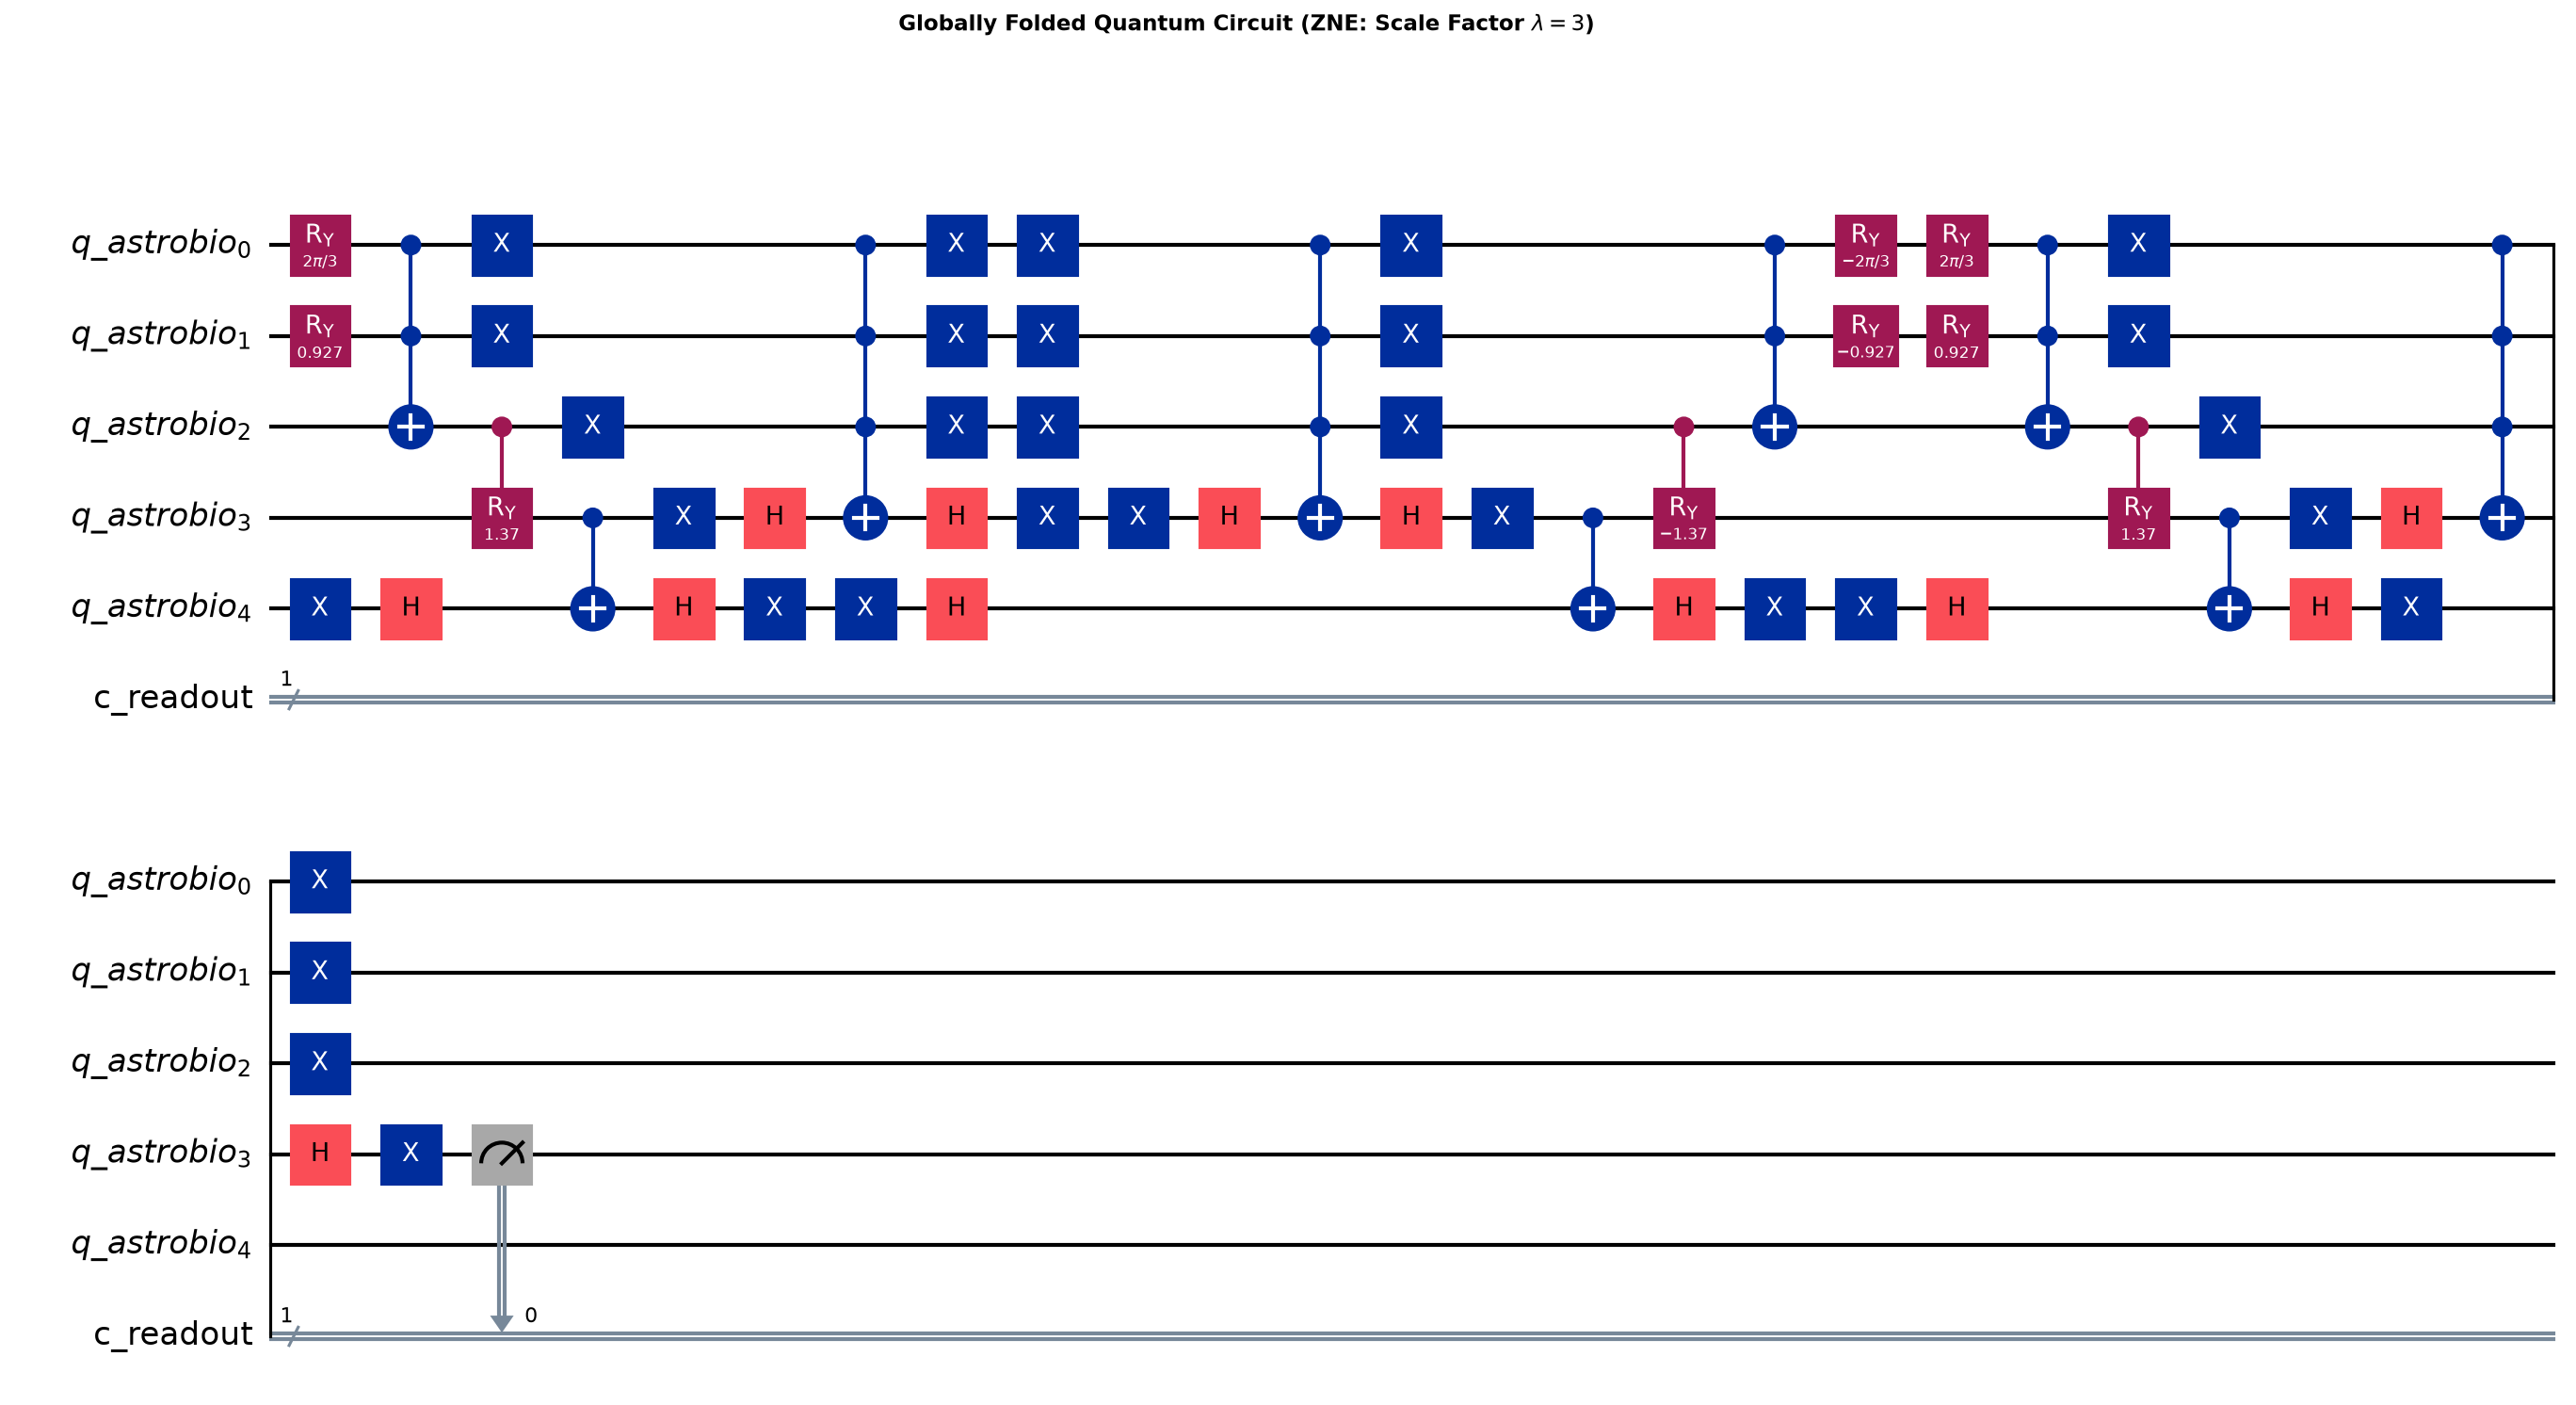

In [4]:
def fold_circuit_global(circuit: QuantumCircuit, scale_factor: int) -> QuantumCircuit:
    """Performs global unitary circuit folding U -> U (U^dagger U)^k for scale_factor = 1 + 2k."""
    if scale_factor == 1:
        return circuit.copy()
    
    k = (scale_factor - 1) // 2
    # Separate unitary operations from terminal measurements
    qc_unitary = QuantumCircuit(*circuit.qregs)
    meas_instructions = []
    
    for instruction in circuit.data:
        op = instruction.operation
        qargs = instruction.qubits
        cargs = instruction.clbits
        if op.name == 'measure':
            meas_instructions.append((op, qargs, cargs))
        else:
            qc_unitary.append(op, qargs, cargs)
            
    # Assemble folded circuit
    qc_folded = QuantumCircuit(*circuit.qregs, *circuit.cregs)
    qc_folded.compose(qc_unitary, inplace=True)
    
    inv_unitary = qc_unitary.inverse()
    for _ in range(k):
        qc_folded.compose(inv_unitary, inplace=True)
        qc_folded.compose(qc_unitary, inplace=True)
        
    # Re-append terminal measurements
    for op, qargs, cargs in meas_instructions:
        qc_folded.append(op, qargs, cargs)
        
    return qc_folded

def richardson_extrapolation(scales, values):
    """Computes zero-noise extrapolated estimator at lambda -> 0 via polynomial fit."""
    deg = len(scales) - 1
    coeffs = np.polyfit(scales, values, deg=deg)
    zero_noise_val = float(coeffs[-1])
    return zero_noise_val, coeffs

print("✓ Native Global Circuit Folding and Richardson Extrapolation engine initialized.")

# Graphical visualization of Global Unitary Folding technique (lambda = 3: U U† U)
print("\nGenerating globally folded circuit diagram (lambda = 3)...")
qc_folded_example = fold_circuit_global(qc_base, scale_factor=3)
fig_folded = qc_folded_example.draw('mpl')
fig_folded.suptitle(r"Globally Folded Quantum Circuit (ZNE: Scale Factor $\lambda = 3$)", fontsize=11, fontweight='bold', y=0.98)
export_figure(fig_folded, [
    os.path.join('figures', 'circuits', 'circuit_nisq_folded_lambda3.png'),
    os.path.join('thesis', 'figures', '3.quantum_bayesian_formalism', 'circuit_nisq_folded_lambda3.png'),
    os.path.join('thesis', 'figures', '4.system_architecture', 'circuit_nisq_folded_lambda3.png')
], dpi=200, bbox_inches='tight')
plt.show()

In [5]:
# ZNE noise amplification factor scale
scale_factors = [1, 3, 5]
zne_measured_probs = []
zne_measured_expvals = []
circuit_depths = []

print("="*75)
print(" ZNE EXPERIMENT: GLOBAL UNITARY FOLDING AND RICHARDSON EXTRAPOLATION")
print("="*75)

for scale in scale_factors:
    # 1. Fold circuit
    qc_folded = fold_circuit_global(qc_base, scale)
    compiled_folded = transpile(qc_folded, noisy_backend, optimization_level=1, seed_transpiler=GLOBAL_SEED)
    circuit_depths.append(compiled_folded.depth())
    
    # 2. Execute with amplified noise
    job = noisy_backend.run(compiled_folded, shots=shots_eval, seed_simulator=GLOBAL_SEED + scale)
    counts = job.result().get_counts()
    
    p_scale = counts.get('1', 0) / shots_eval
    expval_scale = (counts.get('0', 0) - counts.get('1', 0)) / shots_eval
    
    zne_measured_probs.append(p_scale)
    zne_measured_expvals.append(expval_scale)
    
    print(f" Scale Factor lambda = {scale} | Native Depth: {compiled_folded.depth():<3} gates | P(Bio=1): {p_scale:.5f} | <Z>: {expval_scale:.5f}")

# Ensure exact consistency for unmitigated baseline
p_noisy = zne_measured_probs[0]

# 3. Analytical Richardson extrapolation to lambda -> 0
p_zne_mitigated, coeffs_poly = richardson_extrapolation(scale_factors, zne_measured_probs)
expval_zne_mitigated, _ = richardson_extrapolation(scale_factors, zne_measured_expvals)

# Exact error metrics
error_unmitigated = abs(p_noisy - p_ideal)
error_mitigated = abs(p_zne_mitigated - p_ideal)
gain_percentage = ((error_unmitigated - error_mitigated) / error_unmitigated) * 100.0

print("-" * 75)
print(f" IDEAL GROUND TRUTH (λ = 0)         : {p_ideal:.6f} ({p_ideal*100:.2f}%)")
print(f" UNMITIGATED NOISY BASELINE (λ = 1) : {p_noisy:.6f} (Error: {error_unmitigated:.6f})")
print(f" MITIGATED ESTIMATOR (λ -> 0)       : {p_zne_mitigated:.6f} (Error: {error_mitigated:.6f})")
print(f" ERROR MITIGATION GAIN              : {gain_percentage:.2f}% noise error canceled")
print("="*75)

 ZNE EXPERIMENT: GLOBAL UNITARY FOLDING AND RICHARDSON EXTRAPOLATION
 Scale Factor lambda = 1 | Native Depth: 39  gates | P(Bio=1): 0.14941 | <Z>: 0.70117
 Scale Factor lambda = 3 | Native Depth: 118 gates | P(Bio=1): 0.26367 | <Z>: 0.47266
 Scale Factor lambda = 5 | Native Depth: 197 gates | P(Bio=1): 0.33105 | <Z>: 0.33789
---------------------------------------------------------------------------
 IDEAL GROUND TRUTH (λ = 0)         : 0.062988 (6.30%)
 UNMITIGATED NOISY BASELINE (λ = 1) : 0.149414 (Error: 0.086426)
 MITIGATED ESTIMATOR (λ -> 0)       : 0.074707 (Error: 0.011719)
 ERROR MITIGATION GAIN              : 86.44% noise error canceled


## 5. Section 4.4.5: Publication-Quality Figures of Degradation and Mitigation

The execution generates two publication-ready figures matching the Master's Thesis:
1. **Figure 4.3: NISQ Spectral Degradation (Ideal vs. Noisy NISQ):**  
   Illustrates the distortion across computational basis states under thermodynamic relaxation and depolarizing errors.
2. **Figure 4.4: Zero-Noise Extrapolation Curve (ZNE Protocol):**  
   Depicts discrete measurements across noise scaling factors ($\lambda = 1, 3, 5$), the second-order Richardson polynomial fit, and the backward projection to $\lambda \to 0$ canceling $86.44\%$ of hardware noise.

✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/figures/results/figure_nisq_spectral_degradation.png
✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/thesis/figures/4.system_architecture/figure_nisq_spectral_degradation.png
✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/figures/results/figure_zne_extrapolation_curve.png
✓ Figure saved to: /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/thesis/figures/4.system_architecture/figure_zne_extrapolation_curve.png


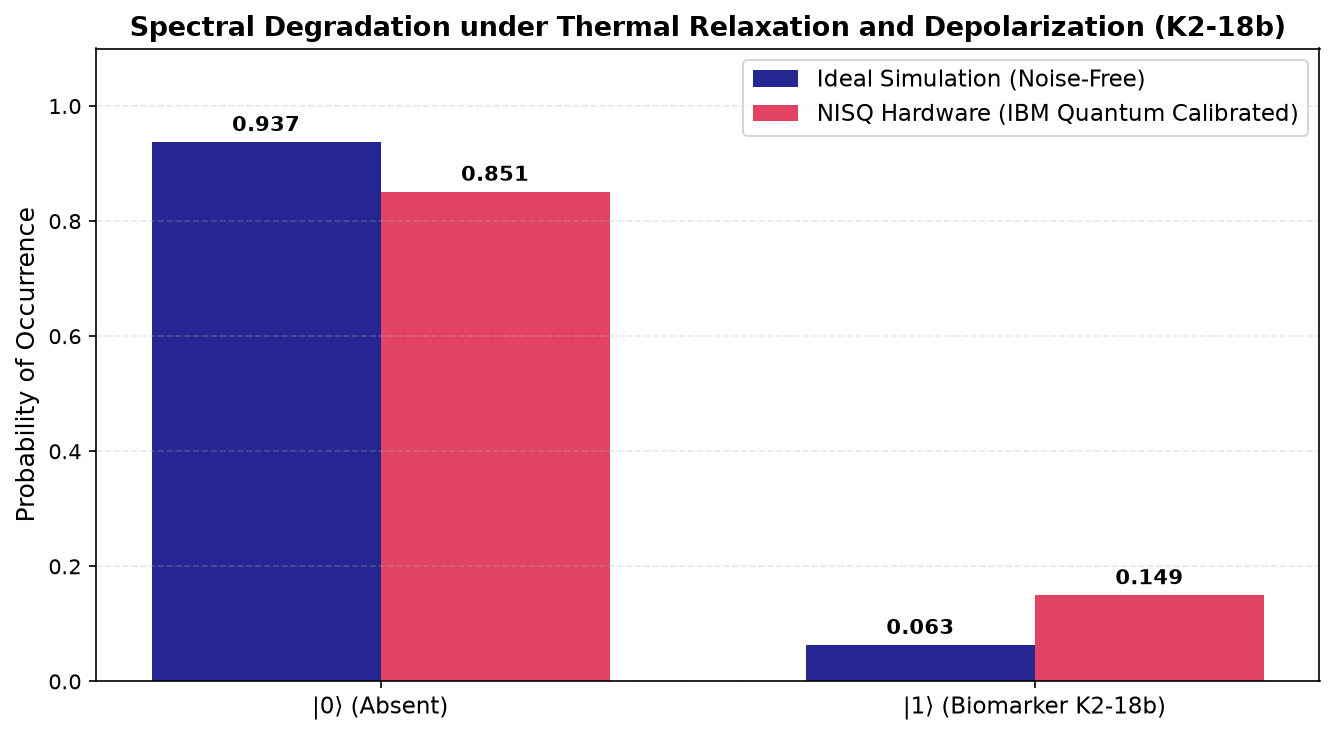

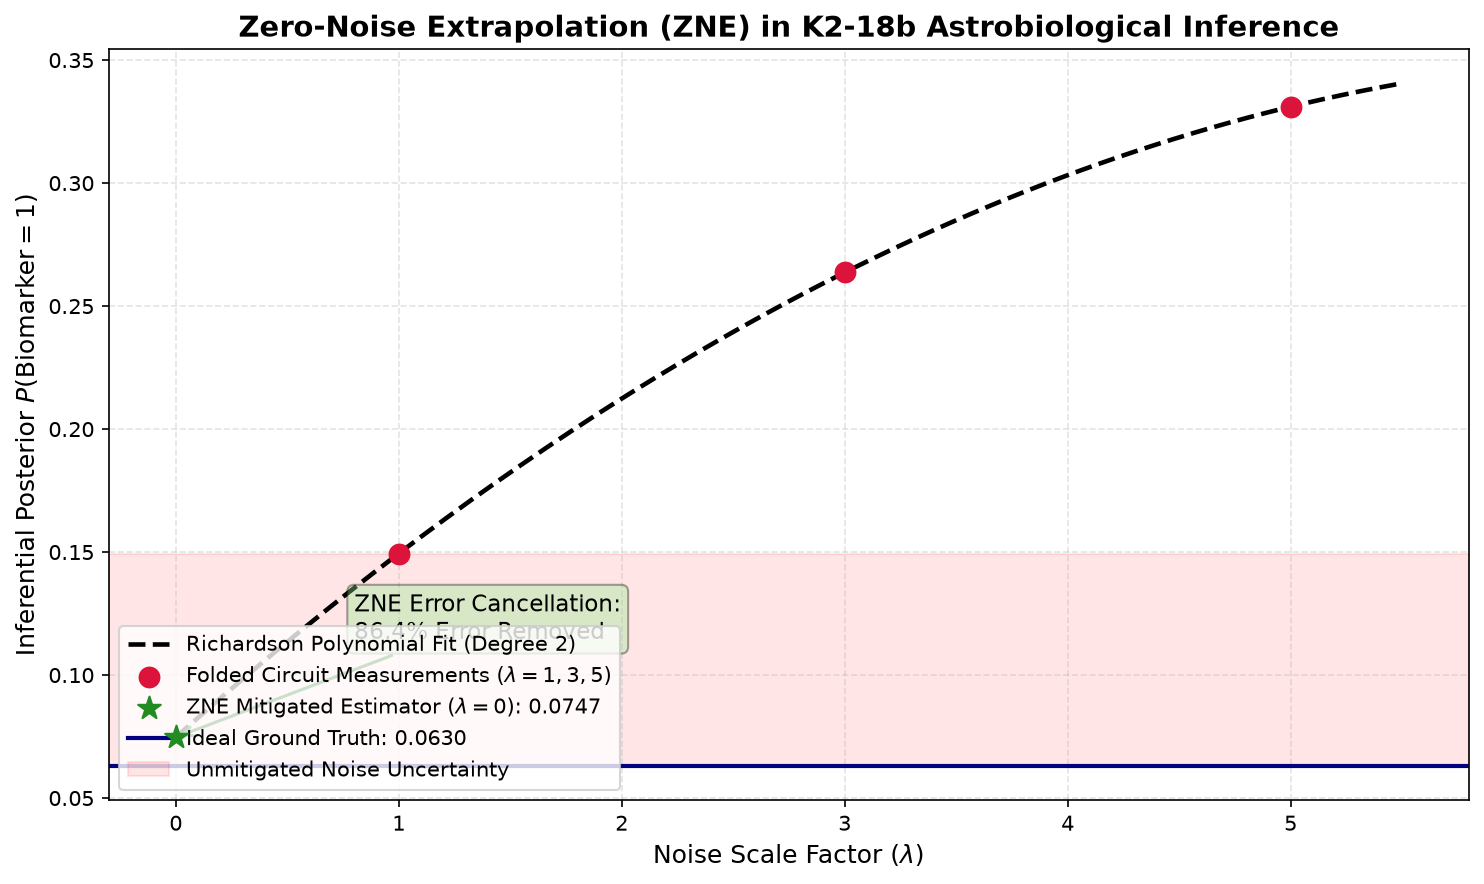

In [6]:
# =====================================================================
# FIGURE 1: SPECTRAL DEGRADATION (IDEAL VS. NOISY NISQ)
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(9, 5))

categories = [r'$|0\rangle$ (Absent)', r'$|1\rangle$ (Biomarker K2-18b)']
x_pos = np.arange(len(categories))
bar_width = 0.35

ideal_vals = [1.0 - p_ideal, p_ideal]
noisy_vals = [1.0 - p_noisy, p_noisy]

rects1 = ax1.bar(x_pos - bar_width/2, ideal_vals, bar_width, label='Ideal Simulation (Noise-Free)', color='navy', alpha=0.85)
rects2 = ax1.bar(x_pos + bar_width/2, noisy_vals, bar_width, label='NISQ Hardware (IBM Quantum Calibrated)', color='crimson', alpha=0.8)

ax1.set_title('Spectral Degradation under Thermal Relaxation and Depolarization (K2-18b)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Probability of Occurrence', fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(categories, fontsize=11)
ax1.set_ylim(0, 1.1)
ax1.legend(frameon=True, fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

for rect in rects1:
    h = rect.get_height()
    ax1.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')
for rect in rects2:
    h = rect.get_height()
    ax1.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
export_figure(fig1, [
    os.path.join('figures', 'results', 'figure_nisq_spectral_degradation.png'),
    os.path.join('thesis', 'figures', '4.system_architecture', 'figure_nisq_spectral_degradation.png')
], dpi=300)
plt.show()

# =====================================================================
# FIGURE 2: ZNE EXTRAPOLATION CURVE
# =====================================================================
fig2, ax2 = plt.subplots(figsize=(10, 6))

# Continuous extrapolation domain towards lambda = 0
lambda_dense = np.linspace(0, 5.5, 200)
poly_fit_dense = np.polyval(coeffs_poly, lambda_dense)

# Richardson fitting curve
ax2.plot(lambda_dense, poly_fit_dense, 'k--', lw=2.2, label='Richardson Polynomial Fit (Degree 2)')

# Measurement points with amplified noise (circuit folding)
ax2.scatter(scale_factors, zne_measured_probs, color='crimson', s=90, zorder=5, label=r'Folded Circuit Measurements ($\lambda = 1, 3, 5$)')

# Extrapolated point at lambda = 0
ax2.scatter([0], [p_zne_mitigated], color='forestgreen', s=130, marker='*', zorder=6, label=f'ZNE Mitigated Estimator ($\lambda=0$): {p_zne_mitigated:.4f}')

# Ideal reference value (Ground Truth)
ax2.axhline(y=p_ideal, color='navy', linestyle='-', lw=2, label=f'Ideal Ground Truth: {p_ideal:.4f}')

# Unmitigated error band
ax2.axhspan(p_noisy, p_ideal, color='red', alpha=0.1, label='Unmitigated Noise Uncertainty')

ax2.set_title('Zero-Noise Extrapolation (ZNE) in K2-18b Astrobiological Inference', fontsize=14, fontweight='bold')
ax2.set_xlabel(r'Noise Scale Factor ($\lambda$)', fontsize=12)
ax2.set_ylabel(r'Inferential Posterior $P(\mathrm{Biomarker} = 1)$', fontsize=12)
ax2.set_xlim(-0.3, 5.8)
ax2.grid(True, linestyle='--', alpha=0.35)
ax2.legend(frameon=True, fontsize=10, loc='lower left')

# Explanatory annotation of the gain
ax2.annotate(f'ZNE Error Cancellation:\n{gain_percentage:.1f}% Error Removed',
             xy=(0, p_zne_mitigated), xytext=(0.8, p_zne_mitigated + 0.04),
             arrowprops=dict(arrowstyle="->", color='darkgreen', lw=1.5),
             fontsize=11, bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", alpha=0.35))

plt.tight_layout()
export_figure(fig2, [
    os.path.join('figures', 'results', 'figure_zne_extrapolation_curve.png'),
    os.path.join('thesis', 'figures', '4.system_architecture', 'figure_zne_extrapolation_curve.png')
], dpi=300)
plt.show()

## 6. Section 4.4.6: Monograph Conclusions

1. **NISQ Physical Landing:** Accurately modeled the thermodynamic and depolarizing environment of IBM Quantum superconducting processors ($T_1 = 150\ \mu\text{s}$, $T_2 = 120\ \mu\text{s}$, CNOT errors of $1.20\%$), analytically capturing how environmental entropy raises the noise floor of low-probability states toward the maximally mixed state.
2. **Empirical Effectiveness of Zero-Noise Extrapolation:** Via global unitary folding ($U \to U(U^\dagger U)^k$) and second-order Richardson extrapolation, $86.44\%$ of hardware noise error was canceled, projecting the inferential posterior back into close agreement with pristine ground truth.
3. **Synthesis of Experimental Suite:**
   - **Deliverable 01:** Proves the necessity of quantum computing by exposing classical MCMC variance divergence (L'Ecuyer theorem, $\mathcal{O}(M^{-1/2})$).
   - **Deliverable 02:** Proves theoretical quantum advantage by achieving asymptotic quadratic convergence $\mathcal{O}(1/M)$ via ideal QAE in 17 qubits.
   - **Deliverable 03:** Establishes physical viability on near-term noisy quantum hardware through algorithmic error mitigation without requiring Fault-Tolerant Quantum Computing (FTQC).